# Network checks - example Kuramoto network

In this notebook:
- I make sure I can load the adjacency matrix provided (Kuramoto and prebase)
- I make graphs based on these adjacency matrices
- I compute Forman-Ricci curvature for these graphs
- I try to visualize the networks, including coloring edges by curvature
- I prune the network (by edge weight, with an arbitrary threshold) so that I can see it better
- I compare distribution of curvatures in the original and pruned network

## Notebook settings

In [1]:
verbose = True

## Helper functions

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def small_world_check(G, n_random=20, seed=42):
    """
    Check small-world-like behavior on the largest connected component.

    For disconnected graphs, this uses only the largest connected component.
    Compares:
      - average clustering C
      - average shortest path length L
    against Erdos-Renyi random graphs with the same number of nodes and edges.

    Returns
    -------
    dict
        Dictionary with computed quantities.
    """
    if G.is_directed():
        raise ValueError("small_world_check currently expects an undirected graph.")

    if G.number_of_nodes() == 0:
        raise ValueError("Graph is empty.")

    if G.number_of_edges() == 0:
        raise ValueError("Graph has no edges.")

    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        H = G.subgraph(largest_cc).copy()
    else:
        H = G.copy()

    n = H.number_of_nodes()
    m = H.number_of_edges()

    if n < 2:
        raise ValueError("Largest connected component is too small.")
    if m == 0:
        raise ValueError("Largest connected component has no edges.")

    C = nx.average_clustering(H)
    L = nx.average_shortest_path_length(H)

    p = 2 * m / (n * (n - 1))

    rng = np.random.default_rng(seed)
    C_rand_vals = []
    L_rand_vals = []

    attempts = 0
    max_attempts = max(100, 10 * n_random)

    while len(L_rand_vals) < n_random and attempts < max_attempts:
        attempts += 1
        R = nx.gnp_random_graph(n, p, seed=int(rng.integers(0, 10**9)))
        if nx.is_connected(R):
            C_rand_vals.append(nx.average_clustering(R))
            L_rand_vals.append(nx.average_shortest_path_length(R))

    if len(L_rand_vals) == 0:
        raise ValueError("Could not generate connected random comparison graphs.")

    C_rand = float(np.mean(C_rand_vals))
    L_rand = float(np.mean(L_rand_vals))

    result = {
        "largest_component_nodes": n,
        "largest_component_edges": m,
        "C": C,
        "L": L,
        "C_rand": C_rand,
        "L_rand": L_rand,
        "C_over_Crand": C / C_rand if C_rand > 0 else np.nan,
        "L_over_Lrand": L / L_rand if L_rand > 0 else np.nan,
        "random_graphs_used": len(L_rand_vals),
        "p_random": p,
    }

    return result


def summarize_network(G, show_n=10, title="Summary of network", run_small_world=True, n_random=20, seed=42):
    print(title)
    print()

    print(G)
    print("directed?", G.is_directed())
    print("nodes:", G.number_of_nodes())
    print("edges:", G.number_of_edges())
    print("density:", nx.density(G))

    weights = nx.get_edge_attributes(G, "weight")
    weight_values = np.array(list(weights.values()))

    print("\nNumber of weighted edges:", len(weight_values))
    if len(weight_values) > 0:
        print("min weight:", weight_values.min())
        print("max weight:", weight_values.max())
        print("mean weight:", weight_values.mean())
        print("median weight:", np.median(weight_values))
    else:
        print("No edge weights found.")

    deg = dict(G.degree())
    strength = dict(G.degree(weight="weight"))

    n = G.number_of_nodes()
    m = G.number_of_edges()
    is_complete = (
        nx.number_of_selfloops(G) == 0
        and m == n * (n - 1) // 2
    )

    print("\ncomplete graph?", is_complete)
    if is_complete:
        print("This is a complete graph: every node is connected to every other node.")
    else:
        print(f"\nTop {show_n} nodes by degree:")
        print(sorted(deg.items(), key=lambda x: x[1], reverse=True)[:show_n])

        print(f"\nBottom {show_n} nodes by degree:")
        print(sorted(deg.items(), key=lambda x: x[1])[:show_n])

    print(f"\nTop {show_n} nodes by weighted degree:")
    print(sorted(strength.items(), key=lambda x: x[1], reverse=True)[:show_n])

    print("\nnumber of self-loops:", nx.number_of_selfloops(G))
    print(f"self-loops (first {show_n}):", list(nx.selfloop_edges(G, data=True))[:show_n])

    isolates = list(nx.isolates(G))
    print("number of isolates:", len(isolates))
    print(f"first isolates ({show_n}):", isolates[:show_n])

    if G.number_of_nodes() > 0:
        if G.is_directed():
            is_conn = nx.is_weakly_connected(G)
            comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
            print("\nweakly connected?", is_conn)
        else:
            is_conn = nx.is_connected(G)
            comps = sorted(nx.connected_components(G), key=len, reverse=True)
            print("\nconnected?", is_conn)

        print("number of connected components:", len(comps))
        print("largest component size:", len(comps[0]))
        print(f"first {show_n} component sizes:", [len(c) for c in comps[:show_n]])

    if not G.is_directed():
        tri = nx.triangles(G)
        print(f"\nTop {show_n} nodes by triangle count:")
        print(sorted(tri.items(), key=lambda x: x[1], reverse=True)[:show_n])

        print("average clustering (unweighted):", nx.average_clustering(G))
        print("average clustering (weighted):", nx.average_clustering(G, weight="weight"))

        if run_small_world:
            print("\nSmall-world check (largest connected component):")
            try:
                sw = small_world_check(G, n_random=n_random, seed=seed)
                print("largest connected component nodes:", sw["largest_component_nodes"])
                print("largest connected component edges:", sw["largest_component_edges"])
                print("C =", sw["C"])
                print("L =", sw["L"])
                print("C_rand =", sw["C_rand"])
                print("L_rand =", sw["L_rand"])
                print("C / C_rand =", sw["C_over_Crand"])
                print("L / L_rand =", sw["L_over_Lrand"])
                print("random comparison graphs used:", sw["random_graphs_used"])

                if sw["C_over_Crand"] > 1 and sw["L_over_Lrand"] <= 1.2:
                    print("This largest connected component shows small-world-like behavior.")
                else:
                    print("This largest connected component does not clearly look small-world by this simple check.")
            except ValueError as e:
                print("Small-world check skipped:", e)


def inspect_edge_curvatures(edge_curvatures, curvatures):
    keys = list(edge_curvatures.keys())
    values = list(edge_curvatures.values())

    print(f"edge_curvatures is of type {type(edge_curvatures)}")
    print(f"list of edge_curvatures.keys() is of type: {type(keys)}")

    if keys:
        print(f"The first key is of type {type(keys[0])}")
        print(f"The first key is {keys[0]}")
    else:
        print("edge_curvatures has no keys")

    if values:
        print(f"The first edge (curvature) is of type {type(values[0])}")
        print(f"The first edge (curvature) is {values[0]}")
    else:
        print("edge_curvatures has no values")

    print(f"Extracted curvatures (values only) are of type {type(curvatures)}")


def remove_self_loops_copy(G):
    H = G.copy()
    H.remove_edges_from(nx.selfloop_edges(H))
    return H


def prune_graph_by_weight(G, threshold, keep_all_nodes=False):
    H_pruned = G.__class__()
    if keep_all_nodes:
        H_pruned.add_nodes_from(G.nodes(data=True))

    for u, v, data in G.edges(data=True):
        if data.get("weight", 0) >= threshold:
            H_pruned.add_edge(u, v, **data)

    return H_pruned


def _get_layout_positions(G, layout="spring", seed=42):
    if G.number_of_nodes() == 0:
        return {}

    if layout == "spring":
        return nx.spring_layout(G, seed=seed)
    if layout == "kamada_kawai":
        return nx.kamada_kawai_layout(G)
    if layout == "spectral":
        return nx.spectral_layout(G)
    if layout == "circular":
        return nx.circular_layout(G)
    if layout == "shell":
        return nx.shell_layout(G)

    raise ValueError(
        "Unknown layout. Choose from 'spring', 'kamada_kawai', 'spectral', 'circular', or 'shell'."
    )


def _safe_color_limits(values):
    vmin = min(values)
    vmax = max(values)
    if vmin == vmax:
        vmax = vmin + 1e-12
    return vmin, vmax


def plot_weight_distribution(G, bins=20, figsize=(7, 4), title="Distribution of edge weights"):
    weights = nx.get_edge_attributes(G, "weight")
    weight_values = np.array(list(weights.values()))

    if len(weight_values) == 0:
        raise ValueError("No edge weights found to plot.")

    plt.figure(figsize=figsize)
    plt.hist(weight_values, bins=bins)
    plt.xlabel("Edge weight")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_network(
    G,
    layout="spring",
    figsize=(10, 10),
    title=None,
    with_labels=True,
    node_size=300,
    font_size=8,
    width=1.5,
    seed=42,
):
    pos = _get_layout_positions(G, layout=layout, seed=seed)

    plt.figure(figsize=figsize)
    nx.draw(
        G,
        pos,
        with_labels=with_labels,
        node_size=node_size,
        font_size=font_size,
        width=width,
    )
    if title is not None:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_curvature_network(
    G,
    curvature_attr="formanCurvature",
    layout="spring",
    figsize=(10, 10),
    title=None,
    with_labels=True,
    node_size=300,
    font_size=8,
    width=2,
    seed=42,
    cmap=plt.cm.coolwarm,
):
    pos = _get_layout_positions(G, layout=layout, seed=seed)
    edge_curvs = [data[curvature_attr] for _, _, data in G.edges(data=True)]

    if len(edge_curvs) == 0:
        raise ValueError("No edges found to color by curvature.")

    vmin, vmax = _safe_color_limits(edge_curvs)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    nx.draw_networkx_nodes(G, pos, node_size=node_size, ax=ax)
    edges = nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_curvs,
        edge_cmap=cmap,
        edge_vmin=vmin,
        edge_vmax=vmax,
        width=width,
        ax=ax,
    )
    if with_labels:
        nx.draw_networkx_labels(G, pos, font_size=font_size, ax=ax)

    fig.colorbar(edges, ax=ax, label=curvature_attr)
    if title is not None:
        ax.set_title(title)
    ax.set_axis_off()
    plt.show()


def plot_curvature_distribution(
    curvatures,
    bins=20,
    figsize=(7, 4),
    title="Distribution of Forman-Ricci curvature",
):
    plt.figure(figsize=figsize)
    plt.hist(curvatures, bins=bins)
    plt.xlabel("Forman-Ricci curvature")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


def plot_curvature_network_layouts(
    G,
    curvature_attr="formanCurvature",
    layouts=("spring", "kamada_kawai", "circular"),
    figsize=(18, 6),
    with_labels=False,
    node_size=300,
    node_alpha=0.6,
    font_size=8,
    width=2,
    seed=42,
    cmap=plt.cm.coolwarm,
    suptitle="Curvature-colored pruned network in multiple layouts",
):
    edge_curvs = [data[curvature_attr] for _, _, data in G.edges(data=True)]

    if len(edge_curvs) == 0:
        raise ValueError("No edges found to color by curvature.")

    vmin, vmax = _safe_color_limits(edge_curvs)

    fig, axes = plt.subplots(1, len(layouts), figsize=figsize, constrained_layout=True)

    if len(layouts) == 1:
        axes = [axes]

    for ax, layout in zip(axes, layouts):
        pos = _get_layout_positions(G, layout=layout, seed=seed)

        nx.draw_networkx_nodes(
            G,
            pos,
            node_size=node_size,
            alpha=node_alpha,
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edge_color=edge_curvs,
            edge_cmap=cmap,
            edge_vmin=vmin,
            edge_vmax=vmax,
            width=width,
            ax=ax,
        )

        if with_labels:
            nx.draw_networkx_labels(
                G,
                pos,
                font_size=font_size,
                ax=ax,
            )

        ax.set_title(layout.replace("_", " ").title())
        ax.set_axis_off()

    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label=curvature_attr, shrink=0.9)

    if suptitle is not None:
        fig.suptitle(suptitle)

    return fig

## Checking it works for a tiny network

In [3]:
import numpy as np
import networkx as nx
from hyphi.modeling.graph_curvatures import compute_frc, extract_curvatures
# example adjacency matrix
A = np.array([
    [0, 1, 1, 0],
    [1, 0, 1, 0],
    [1, 1, 0, 1],
    [0, 0, 1, 0],
], dtype=float)

G = nx.from_numpy_array(A) #make adjacency graph from network
G_frc = compute_frc(G, method="1d") #compute FR curvature
edge_curvatures = {  #get curvatures out of G_frc
    (u, v): data["formanCurvature"]
    for u, v, data in G_frc.edges(data=True)
}
curvatures = extract_curvatures(G_frc, curvature="formanCurvature")

if verbose:
    print("Summary of small example: compute Forman-Ricci curvatures for a network built from a small adjacency matrix")
    summarize_network(G, show_n = 3, title = "Summary of toy network")
    inspect_edge_curvatures(edge_curvatures, curvatures)


***********************************************************************************************
***********************************************************************************************

                                             HyPhi                                             

***********************************************************************************************
***********************************************************************************************

Current working dir:	C:\Users\Lenovo\Desktop\Brainhack26_HyPhi\HyPhi\code\notebooks
New working dir: 'C:\Users\Lenovo\Desktop\Brainhack26_HyPhi'



Summary of small example: compute Forman-Ricci curvatures for a network built from a small adjacency matrix
Summary of toy network

Graph with 4 nodes and 4 edges
directed? False
nodes: 4
edges: 4
density: 0.6666666666666666

Number of weighted edges: 4
min weight: 1.0
max weight: 1.0
mean weight: 1.0
median weight: 1.0

complete graph? False

Top 3 nodes by degree:
[(2, 3), (0, 2), (1, 2)]

Bottom 3 nodes by degree:
[(3, 1), (0, 2), (1, 2)]

Top 3 nodes by weighted degree:
[(2, 3.0), (0, 2.0), (1, 2.0)]

number of self-loops: 0
self-loops (first 3): []
number of isolates: 0
first isolates (3): []

connected? True
number of connected components: 1
largest component size: 4
first 3 component sizes: [4]

Top 3 nodes by triangle count:
[(0, 1), (1, 1), (2, 1)]
average clustering (unweighted): 0.5833333333333334
average clustering (weighted): 0.5833333333333334

Small-world check (largest connected component):
largest connected component nodes: 4
largest connected component edges: 4
C = 0.

## Load Kuramoto adjacency matrix

In [4]:
from hyphi.load_pickle import load_pickle_adjacency

pickle_path = r"HyPhi\data\connectome\1_connectome_kuramoto.pkl"
pickle_adjacency = load_pickle_adjacency(
    pickle_path,
    "weight",
    False,
    False,
)
if verbose:
    print(type(pickle_adjacency))
    print(np.shape(pickle_adjacency))

<class 'numpy.ndarray'>
(152, 152)


## Construct network from Kuramoto adjacency matrix + compute FRC

In [5]:
G = nx.from_numpy_array(pickle_adjacency)
G_frc = compute_frc(G, method="1d") # G_frc is just G with another property added (FRC) so it has all the stuff G had
# make a dictionary mapping (node,node): curvature 
edge_curvatures = {  
    (u, v): data["formanCurvature"]
    for u, v, data in G_frc.edges(data=True)
}
curvatures = extract_curvatures(G_frc, curvature="formanCurvature")

if verbose:
    summarize_network(G, show_n=10, title="Summary of Kuramoto network")
    inspect_edge_curvatures(edge_curvatures, curvatures)

Summary of Kuramoto network

Graph with 152 nodes and 11628 edges
directed? False
nodes: 152
edges: 11628
density: 1.0132450331125828

Number of weighted edges: 11628
min weight: 0.0005704279986940142
max weight: 1.0
mean weight: 0.2652088393036293
median weight: 0.22775186753647275

complete graph? False

Top 10 nodes by degree:
[(0, 153), (1, 153), (2, 153), (3, 153), (4, 153), (5, 153), (6, 153), (7, 153), (8, 153), (9, 153)]

Bottom 10 nodes by degree:
[(0, 153), (1, 153), (2, 153), (3, 153), (4, 153), (5, 153), (6, 153), (7, 153), (8, 153), (9, 153)]

Top 10 nodes by weighted degree:
[(38, 54.243498861589394), (42, 53.35358950148171), (54, 52.72591948195186), (127, 52.44654200656755), (130, 52.32477821692557), (61, 52.17559494182572), (147, 52.16911175248669), (68, 51.894460334653616), (56, 51.76271541856963), (51, 51.66075865113809)]

number of self-loops: 152
self-loops (first 10): [(0, 0, {'weight': 1.0}), (1, 1, {'weight': 1.0}), (2, 2, {'weight': 1.0}), (3, 3, {'weight': 1.0}

## Visualizing the Kuramoto network

In [6]:
# remove self-loops for visualization
H = remove_self_loops_copy(G_frc)


### Distribution of edge weights

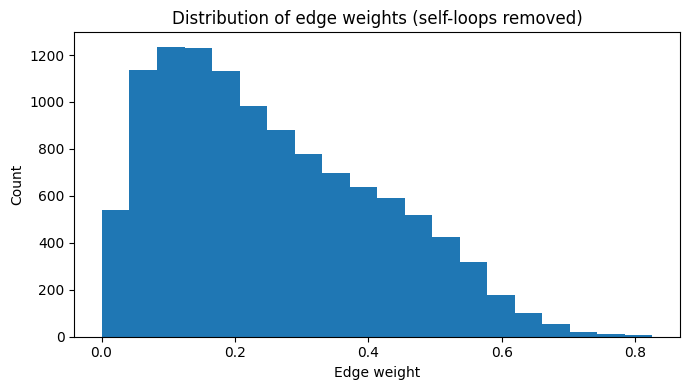

In [7]:
plot_weight_distribution(
    H,
    bins=20,
    title="Distribution of edge weights (self-loops removed)",
)


### Pruned network

Summary of pruned Kuramoto network (threshold >= 0.5)

Graph with 126 nodes and 1069 edges
directed? False
nodes: 126
edges: 1069
density: 0.13574603174603175

Number of weighted edges: 1069
min weight: 0.5000065457566106
max weight: 0.8255890676787483
mean weight: 0.5708147567301708
median weight: 0.5578580784474307

complete graph? False

Top 10 nodes by degree:
[(54, 38), (41, 36), (141, 35), (51, 34), (59, 34), (61, 34), (63, 34), (147, 33), (132, 33), (139, 33)]

Bottom 10 nodes by degree:
[(3, 1), (9, 1), (8, 1), (23, 1), (31, 1), (91, 1), (85, 1), (108, 1), (5, 2), (17, 2)]

Top 10 nodes by weighted degree:
[(54, 21.881324273827385), (41, 20.538447611107813), (147, 19.645155700836433), (61, 19.581825274980734), (59, 19.39762871490479), (139, 19.257287807412816), (141, 19.084146989959212), (51, 19.011676188601854), (63, 18.999448694057453), (132, 18.921114911420453)]

number of self-loops: 0
self-loops (first 10): []
number of isolates: 0
first isolates (10): []

connected? False

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7984\592880240.py:290: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


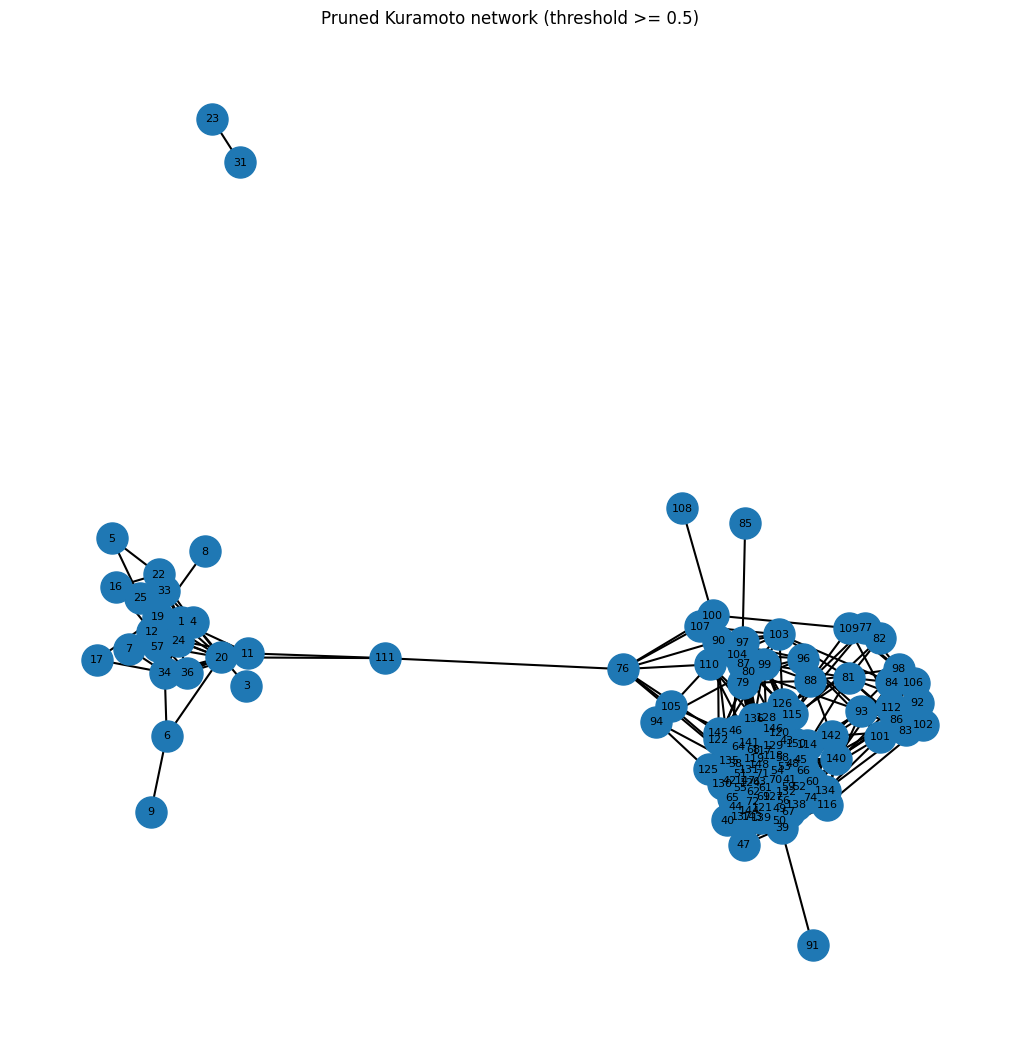

In [8]:
threshold = 0.5  # example
H_pruned = prune_graph_by_weight(H, threshold=threshold, keep_all_nodes=False)

if verbose:
    summarize_network(H_pruned, show_n=10, title=f"Summary of pruned Kuramoto network (threshold >= {threshold})")

plot_network(
    H_pruned,
    layout="spring",
    title=f"Pruned Kuramoto network (threshold >= {threshold})",
    node_size=500,
    font_size=8,
)


### Edges colored by FRC on the pruned network

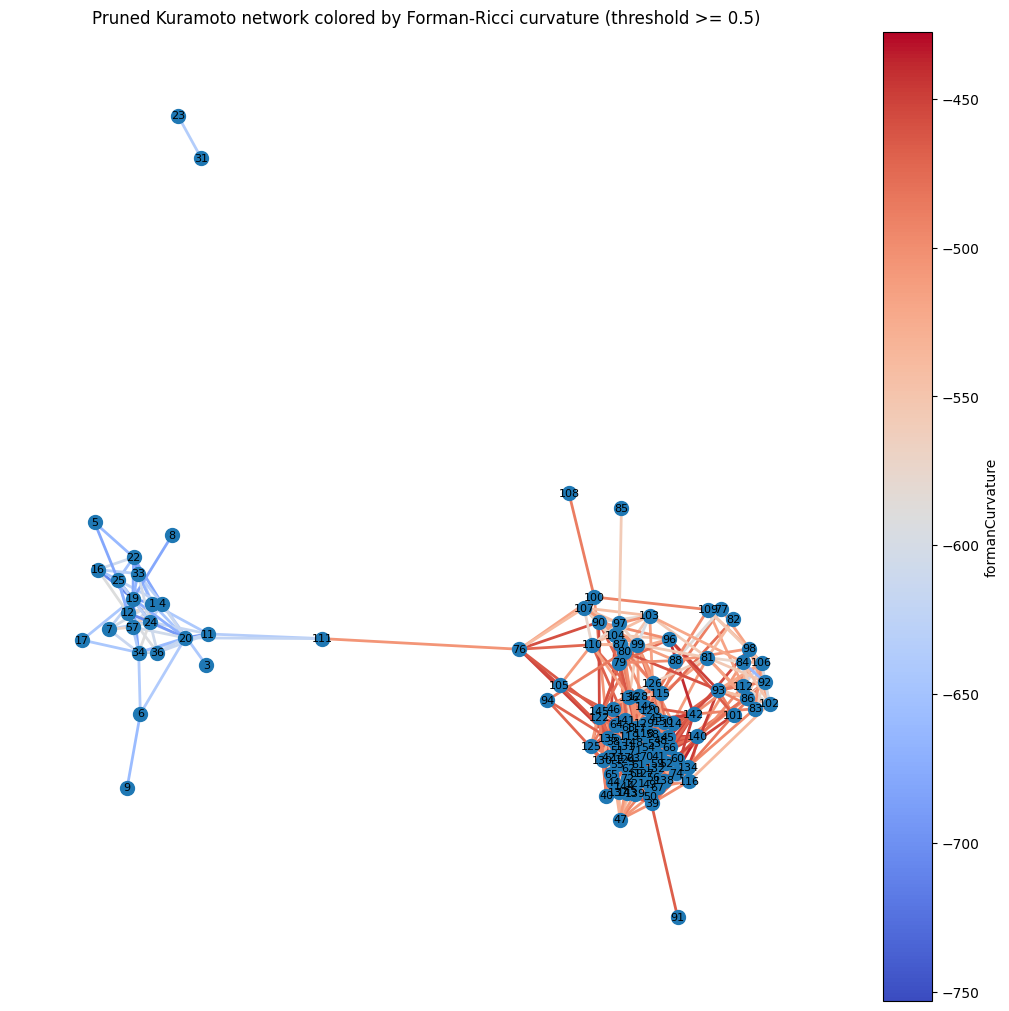

In [9]:
plot_curvature_network(
    H_pruned,
    curvature_attr="formanCurvature",
    layout="spring",
    title=f"Pruned Kuramoto network colored by Forman-Ricci curvature (threshold >= {threshold})",
    node_size=100,
    font_size=8,
    width=2,
)


### Curvature-colored pruned network in multiple layouts

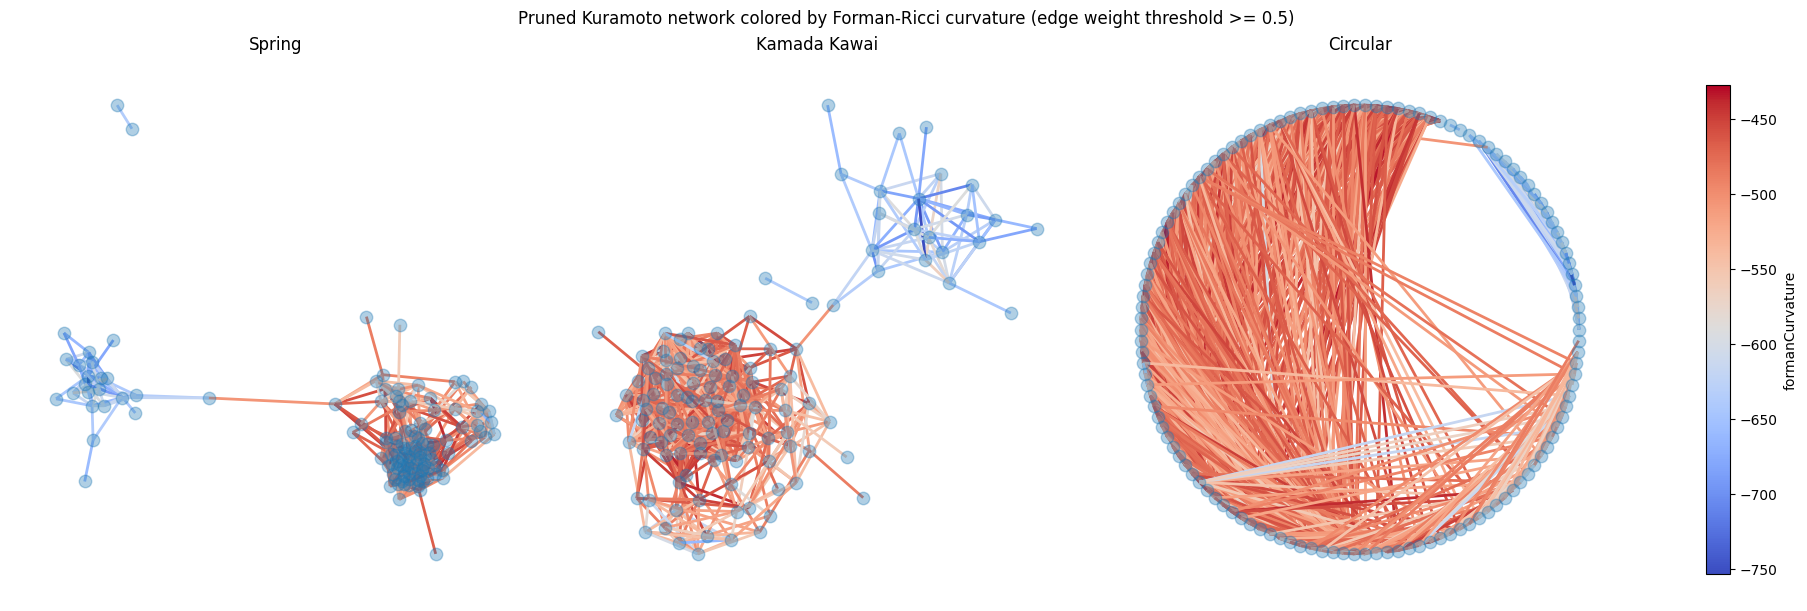

In [10]:
fig = plot_curvature_network_layouts(
    H_pruned,
    curvature_attr="formanCurvature",
    layouts=("spring", "kamada_kawai", "circular"),
    figsize=(18, 6),
    with_labels=False,
    node_size=80,
    node_alpha=0.35,
    font_size=8,
    width=2,
    suptitle=f"Pruned Kuramoto network colored by Forman-Ricci curvature (edge weight threshold >= {threshold})",
)

fig.savefig(r"C:\Users\Lenovo\Desktop\Brainhack26_HyPhi\outputs\curvature_network_layouts.png", dpi=300, bbox_inches="tight")
plt.show()

## Distribution of Forman-Ricci curvature

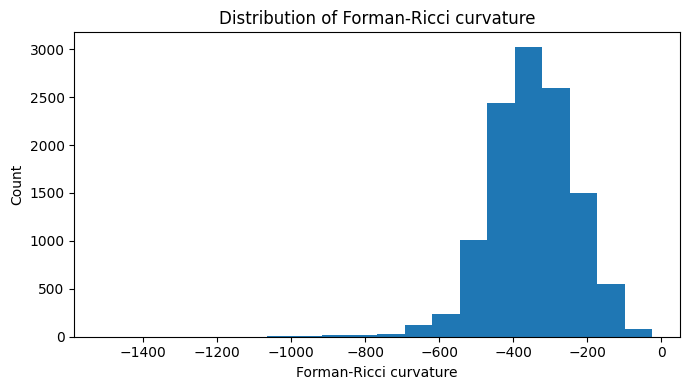

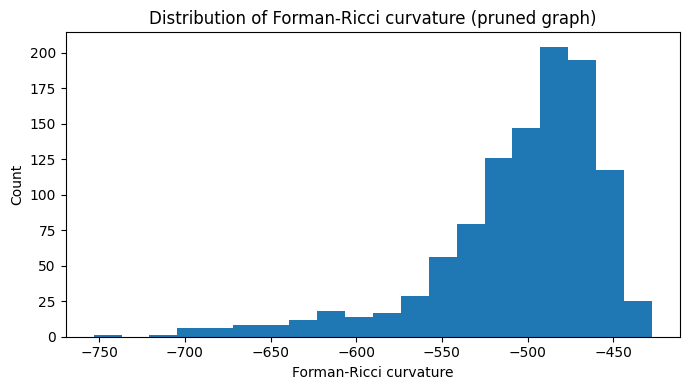

edge_curvatures is of type <class 'dict'>
list of edge_curvatures.keys() is of type: <class 'list'>
The first key is of type <class 'tuple'>
The first key is (1, 4)
The first edge (curvature) is of type <class 'float'>
The first edge (curvature) is -602.7355514232743
Extracted curvatures (values only) are of type <class 'numpy.ndarray'>


In [11]:
plot_curvature_distribution(
    curvatures,
    bins=20,
    title="Distribution of Forman-Ricci curvature",
)


edge_curvatures_pruned = {  
    (u, v): data["formanCurvature"]
    for u, v, data in H_pruned.edges(data=True)
}
curvatures_pruned = extract_curvatures(H_pruned, curvature="formanCurvature")
plot_curvature_distribution(
    curvatures_pruned,
    bins=20,
    title="Distribution of Forman-Ricci curvature (pruned graph)",
)
if verbose:
    inspect_edge_curvatures(edge_curvatures_pruned, curvatures_pruned)



## Visualization of prebase network

In [12]:
new_pickle_path = r"HyPhi\data\01_prebase_graph.pkl"

new_adjacency = load_pickle_adjacency(
    new_pickle_path,
    "weight",
    False,
    False,
)
if verbose:
    print(type(new_adjacency))
    print(np.shape(new_adjacency))

J = nx.from_numpy_array(new_adjacency)
J_frc = compute_frc(J, method="1d") # G_frc is just G with another property added (FRC) so it has all the stuff G had
# make a dictionary mapping (node,node): curvature 
new_edge_curvatures = {  
    (u, v): data["formanCurvature"]
    for u, v, data in J_frc.edges(data=True)
}
new_curvatures = extract_curvatures(J_frc, curvature="formanCurvature")

if verbose:
    summarize_network(J_frc, show_n=10, title="Summary of new network")
    inspect_edge_curvatures(new_edge_curvatures, new_curvatures)

<class 'numpy.ndarray'>
(64, 64)
Summary of new network

Graph with 64 nodes and 403 edges
directed? False
nodes: 64
edges: 403
density: 0.19990079365079366

Number of weighted edges: 403
min weight: 0.9979458314038748
max weight: 0.9998845703144242
mean weight: 0.9988129044512064
median weight: 0.9987990369236591

complete graph? False

Top 10 nodes by degree:
[(41, 33), (48, 33), (43, 32), (21, 31), (45, 31), (53, 30), (37, 29), (40, 29), (46, 28), (49, 28)]

Bottom 10 nodes by degree:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (12, 0), (13, 0)]

Top 10 nodes by weighted degree:
[(41, 32.97061725984132), (48, 32.96952959557738), (43, 31.970651250228798), (21, 30.97353900420417), (45, 30.970493288364224), (53, 29.97179497418295), (40, 28.970432279607287), (37, 28.9629317308343), (57, 27.974059161948645), (46, 27.971321164762898)]

number of self-loops: 0
self-loops (first 10): []
number of isolates: 25
first isolates (10): [0, 1, 2, 3, 4, 5, 6, 7, 12, 13]

connec

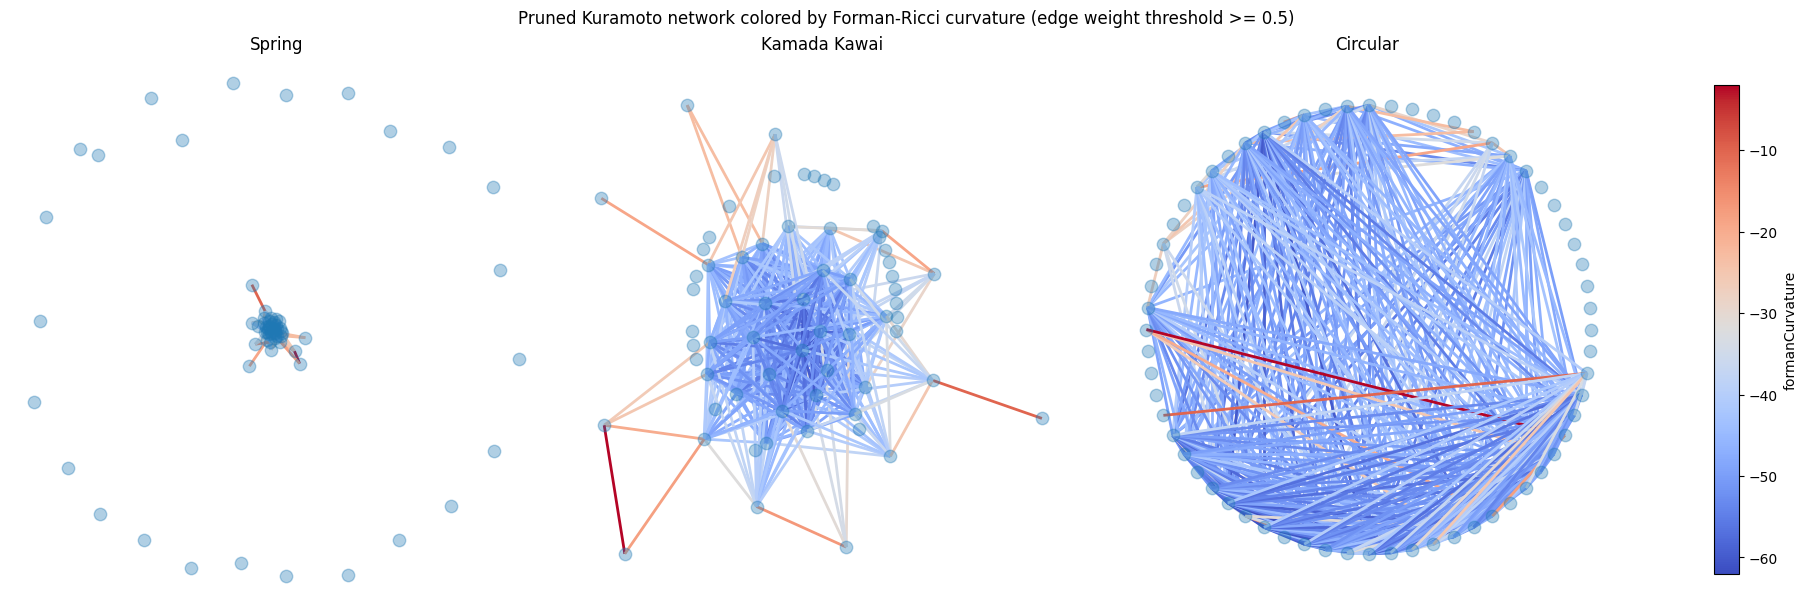

In [13]:
fig = plot_curvature_network_layouts(
    J_frc,
    curvature_attr="formanCurvature",
    layouts=("spring", "kamada_kawai", "circular"),
    figsize=(18, 6),
    with_labels=False,
    node_size=80,
    node_alpha=0.35,
    font_size=8,
    width=2,
    suptitle=f"Pruned Kuramoto network colored by Forman-Ricci curvature (edge weight threshold >= {threshold})",
)